# 01 - Data exploration & quality
_Vittora Credit (fictional) - synthetic data._

Goal: understand the shape of the 11 source tables, how they relate, and what the data-quality framework found before trusting any metric.

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
import duckdb, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from python import visualize as viz   # shared chart style (palette, fonts, grid)
%matplotlib inline
from python.config import get_settings
S = get_settings(base_dir=ROOT)
con = duckdb.connect(str(S.warehouse_path), read_only=True)
q = lambda sql: con.execute(sql).df()
pd.set_option("display.max_columns", 30); pd.set_option("display.width", 160)
print("Warehouse:", S.warehouse_path.name, "| as of", S.end_date, "| SYNTHETIC DATA")

Warehouse: fintech.duckdb | as of 2026-06-30 | SYNTHETIC DATA


## Row counts across the curated layer

In [2]:
tables = [r[0] for r in con.execute("SELECT table_name FROM information_schema.tables WHERE table_schema='core' ORDER BY 1").fetchall()]
counts = pd.DataFrame({'table': tables, 'rows': [con.execute(f'SELECT COUNT(*) FROM core.{t}').fetchone()[0] for t in tables]})
print('total rows:', format(counts.rows.sum(), ','))
counts.sort_values('rows', ascending=False)

total rows: 1,247,836


,table,rows
6,product_events,828637
10,transactions,130997
8,repayments,125584
1,customers,81200
0,applications,46871
4,loans,20661
2,experiment_assignments,7308
9,support_tickets,6446
5,marketing_campaigns,122
7,products,7


## Who are the customers?

In [3]:
q("""SELECT acquisition_channel, signup_platform, COUNT(*) AS customers,
       ROUND(AVG(monthly_income)) AS avg_income, ROUND(100*AVG(CASE WHEN is_ntc THEN 1 ELSE 0 END),1) AS ntc_pct
FROM core.customers GROUP BY 1,2 ORDER BY customers DESC LIMIT 12""")

,acquisition_channel,signup_platform,customers,avg_income,ntc_pct
0,paid_social,android,14379,43965.0,24.1
1,organic,android,14211,44800.0,24.3
2,paid_search,android,10731,44742.0,23.7
3,affiliate,android,8906,43982.0,35.9
4,referral,android,7641,43852.0,24.4
5,partnerships,android,5608,46229.0,16.6
6,paid_social,ios,3178,44111.0,23.0
7,organic,ios,3114,44973.0,24.1
8,paid_search,web,2928,43825.0,22.9
9,paid_search,ios,2652,43987.0,24.4


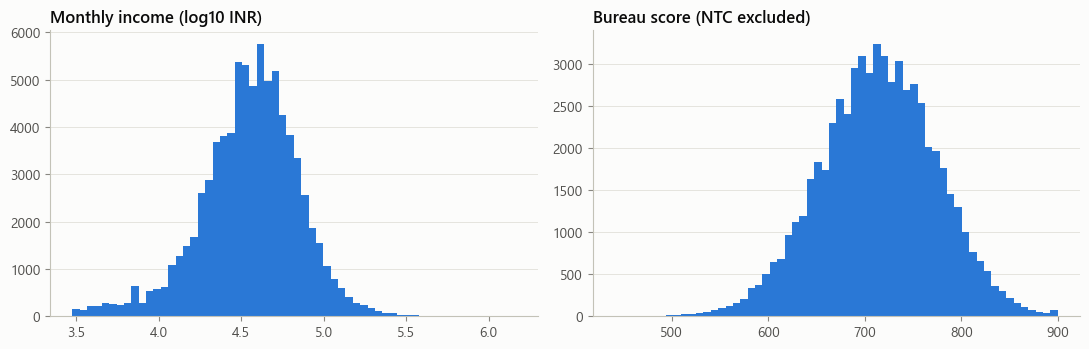

In [4]:
c = q('SELECT monthly_income, credit_score, employment_type FROM core.customers')
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hist(np.log10(c.monthly_income.dropna()), bins=60, color=viz.SERIES[0]); axes[0].set_title('Monthly income (log10 INR)')
axes[1].hist(c.credit_score.dropna(), bins=60, color=viz.SERIES[0]); axes[1].set_title('Bureau score (NTC excluded)')
plt.tight_layout(); plt.show()

## Data-quality results (raw extract vs curated layer)
Every defect the generator planted is listed in `data/raw/_injected_issues.json`; the framework's job is to catch all of them.

In [5]:
dq = json.loads((S.outputs_dir/'data_quality'/'dq_summary.json').read_text())
pd.DataFrame({k: {m: dq[k][m] for m in ['checks_run','dq_score','critical_failures','warnings']} for k in ['raw','clean']})

,raw,clean
checks_run,400.0,404.0
dq_score,92.0,99.1
critical_failures,22.0,0.0
warnings,11.0,9.0


In [6]:
pd.read_csv(S.outputs_dir/'data_quality'/'injected_issue_recall.csv')[['table','column','issue','rows_affected','detected']]

,table,column,issue,rows_affected,detected
0,customers,acquisition_channel,inconsistent category casing/spacing,487,True
1,customers,city,missing city,974,True
2,customers,monthly_income,missing income,1624,True
3,customers,age,impossible age,65,True
4,customers,credit_score,bureau score outside 300-900,30,True
5,customers,monthly_income,income keyed with two extra zeros,119,True
6,customers,kyc_completed_ts,UTC timestamp written into IST column (KYC ven...,579,True
7,customers,customer_id,duplicate rows re-sent by CRM sync,325,True
8,applications,requested_amount,negative requested amount,23,True
9,applications,decision_ts,decision before submission,31,True


In [7]:
pd.read_csv(S.outputs_dir/'data_quality'/'cleaning_log.csv').query('rows_affected > 0')

,table,rule,action,rows_affected,detail
4,marketing_campaigns,start_date after end_date -> swapped,repair,1,NaN
5,marketing_campaigns,spend > 150% of budget -> flagged for Finance ...,flag,1,CMP-202510-PTN
7,customers,exact duplicate rows,drop_duplicate,325,NaN
9,customers,acquisition_channel casing/spacing standardised,standardise,487,NaN
10,customers,acquisition_channel contradicts campaign tag -...,repair,400,NaN
11,customers,credit_score outside 300-900 -> null (is_ntc s...,nullify,30,NaN
12,customers,age outside 18-75 -> null,nullify,65,NaN
13,customers,monthly_income > 15L/month keyed with extra ze...,repair,106,NaN
14,customers,kyc_completed_ts written in UTC (precedes kyc_...,repair,579,NaN
17,applications,exact duplicate rows,drop_duplicate,117,NaN


**Takeaway:** the curated layer has no critical issues; the remaining warnings (missing city/income, a flagged campaign over budget, the KYC tracking gap) are documented and carried into report caveats.